In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import math
import numpy as np
import seaborn as sns
import polars as pl

from catboost import Pool, CatBoostClassifier
from sklearn.metrics import roc_auc_score

## Данные(features)

In [2]:
train_main = pl.read_parquet('data/train_main_features.parquet')
train_extra = pl.read_parquet('data/train_extra_features.parquet')
test = pl.read_parquet('data/test_main_features.parquet')

print('Главные данные:', train_main.shape)
print('Экстра данные:', train_extra.shape)
print('Тестовые данные:', test.shape)

Главные данные: (750000, 200)
Экстра данные: (750000, 2242)
Тестовые данные: (250000, 200)


#### Пропущенные значения

In [3]:
missing_values_main = (
    train_main.null_count()
    .unpivot(variable_name="Column", value_name="Missing Values")
    .filter(pl.col("Missing Values") > 600000)
    .sort("Missing Values", descending=True)
)

print('\nКоличество пропусков в признаках:\n', missing_values_main)


Количество пропусков в признаках:
 shape: (34, 2)
┌─────────────────┬────────────────┐
│ Column          ┆ Missing Values │
│ ---             ┆ ---            │
│ str             ┆ u32            │
╞═════════════════╪════════════════╡
│ num_feature_43  ┆ 749166         │
│ num_feature_54  ┆ 748897         │
│ num_feature_64  ┆ 748761         │
│ num_feature_34  ┆ 748228         │
│ num_feature_118 ┆ 747082         │
│ …               ┆ …              │
│ num_feature_91  ┆ 618652         │
│ num_feature_121 ┆ 618652         │
│ num_feature_127 ┆ 618652         │
│ num_feature_125 ┆ 612632         │
│ num_feature_70  ┆ 604994         │
└─────────────────┴────────────────┘


In [4]:
for i in missing_values_main['Column']:
    train_main = train_main.drop(i)

In [5]:
train_main.head()

customer_id,cat_feature_1,cat_feature_2,cat_feature_3,cat_feature_4,cat_feature_5,cat_feature_6,cat_feature_7,cat_feature_8,cat_feature_9,cat_feature_10,cat_feature_11,cat_feature_12,cat_feature_13,cat_feature_14,cat_feature_15,cat_feature_16,cat_feature_17,cat_feature_18,cat_feature_19,cat_feature_20,cat_feature_21,cat_feature_22,cat_feature_23,cat_feature_24,cat_feature_25,cat_feature_26,cat_feature_27,cat_feature_28,cat_feature_29,cat_feature_30,cat_feature_31,cat_feature_32,cat_feature_33,cat_feature_34,cat_feature_35,cat_feature_36,…,num_feature_88,num_feature_89,num_feature_90,num_feature_92,num_feature_93,num_feature_94,num_feature_95,num_feature_96,num_feature_97,num_feature_98,num_feature_99,num_feature_100,num_feature_101,num_feature_102,num_feature_103,num_feature_104,num_feature_105,num_feature_106,num_feature_107,num_feature_108,num_feature_109,num_feature_111,num_feature_113,num_feature_114,num_feature_115,num_feature_116,num_feature_117,num_feature_119,num_feature_120,num_feature_122,num_feature_123,num_feature_124,num_feature_126,num_feature_129,num_feature_130,num_feature_131,num_feature_132
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1000001,1.0,0.0,2.0,1.0,2.0,3.0,2.0,2.0,4.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,212.0,0.0,0.0,…,null,null,-0.369955,-0.046292,-0.00859,-0.126543,-0.143428,-0.284519,null,-0.004499,null,-0.050159,-0.002297,-0.043592,-0.061488,0.450342,null,0.0,null,-0.060492,-0.279105,-0.429813,-0.009654,-0.293036,null,-0.493959,-0.019079,null,null,-0.001357,-0.031281,-0.046146,-0.445279,-0.107666,-0.418616,null,null
1000002,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,212.0,1.0,0.0,…,null,-0.008539,0.688359,-0.046292,-0.00859,1.167873,-0.163148,-0.284519,0.460275,-0.004278,null,-0.556244,-0.002297,-0.043592,-0.061488,1.998252,-0.009552,0.0,-0.005762,-0.060492,-0.279105,-0.429813,-0.009654,-0.293036,-0.004421,-0.256445,-0.014154,-0.24167,null,-0.001357,-0.031281,-0.046146,1.550722,-0.170724,-0.805771,-0.397803,-0.373734
1000003,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,212.0,0.0,0.0,…,null,-0.008539,-0.369955,-0.046292,-0.00859,-0.234411,-0.234203,-0.284519,-0.264397,-0.004278,null,null,-0.002297,-0.043592,-0.061488,-0.264078,null,0.0,-0.26649,-0.060492,-0.279105,-0.429813,-0.009654,-0.293036,-0.004421,-0.57313,-0.019124,-0.24167,null,-0.001357,-0.031281,-0.046146,-0.475778,-0.170724,-0.602005,-0.397803,-0.373734
1000004,1.0,0.0,2.0,1.0,2.0,3.0,2.0,2.0,3.0,2.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,2.0,0.0,0.0,212.0,0.0,0.0,…,null,null,-0.193569,-0.046292,-0.00859,-0.342279,null,-0.284519,null,-0.004499,null,null,-0.002297,-0.043592,-0.061488,0.688482,-0.009552,0.0,null,-0.060492,null,-0.429813,-0.009654,-0.293036,null,-0.57313,null,-0.505441,null,-0.001357,-0.031281,-0.046146,-0.475778,null,-0.724265,null,null
1000005,1.0,2.0,0.0,1.0,0.0,3.0,0.0,0.0,2.0,1.0,2.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,212.0,2.0,2.0,…,null,-0.008539,-0.369955,null,null,null,0.276901,-0.284519,-0.264397,-0.004499,null,null,-0.002297,-0.043592,null,-0.264078,null,0.0,-0.26649,null,-0.279105,-0.429813,-0.009654,-0.293036,-0.004421,-0.57313,-0.018674,null,null,null,null,-0.046146,null,-0.107666,null,-0.397803,-0.373734


In [6]:
missing_values_extra = (
    train_extra.null_count()
    .unpivot(variable_name="Column", value_name="Missing Values")
    .filter(pl.col("Missing Values") > 600000)
    .sort("Missing Values", descending=True)
)

print('\nКоличество пропусков в признаках:\n', missing_values_extra)


Количество пропусков в признаках:
 shape: (911, 2)
┌──────────────────┬────────────────┐
│ Column           ┆ Missing Values │
│ ---              ┆ ---            │
│ str              ┆ u32            │
╞══════════════════╪════════════════╡
│ num_feature_923  ┆ 749998         │
│ num_feature_1792 ┆ 749996         │
│ num_feature_1058 ┆ 749993         │
│ num_feature_1832 ┆ 749993         │
│ num_feature_1695 ┆ 749992         │
│ …                ┆ …              │
│ num_feature_1913 ┆ 604085         │
│ num_feature_1455 ┆ 602636         │
│ num_feature_259  ┆ 601448         │
│ num_feature_2090 ┆ 600843         │
│ num_feature_426  ┆ 600566         │
└──────────────────┴────────────────┘


In [7]:
for i in missing_values_extra['Column']:
    train_extra = train_extra.drop(i)

## Целевые переменные

In [8]:
target = pl.read_parquet('data/train_target.parquet')

Дропнем айдишники

In [9]:
import polars.selectors as cs

# Drop id-like columns only if they exist (avoid dropping real targets)
id_like = [
    c for c in target.columns
    if c.lower() in ("id", "index") or c.lower().endswith("_id")
]
if id_like:
    target = target.drop(id_like)

target

target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,target_2_6,target_2_7,target_2_8,target_3_1,target_3_2,target_3_3,target_3_4,target_3_5,target_4_1,target_5_1,target_5_2,target_6_1,target_6_2,target_6_3,target_6_4,target_6_5,target_7_1,target_7_2,target_7_3,target_8_1,target_8_2,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Нет клиентов без продуктов, поэтому не можем отсеять тех, кто не пользуется продуктами

In [10]:
zero_rows_count = target.filter(pl.sum_horizontal(pl.all().abs()) == 0).height
zero_rows_count

0

Полезный график: встречаемость каждого продукта в dataframe

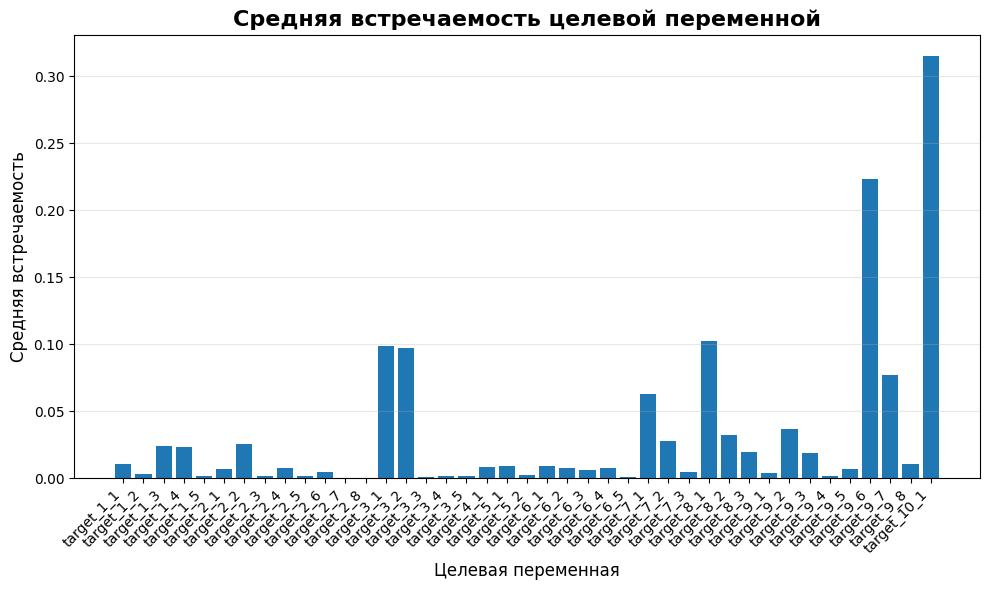

In [11]:
target_columns = [col for col in target.columns if col.startswith("target")]
target_col_means = (
    target.select(pl.col(target_columns).mean())
    .transpose(include_header = True, column_names = ["Mean"])
    .rename({"column": "Target"})
    #.sort("Sum", descending=True)
)
plt.figure(figsize = (10, 6))

bars = plt.bar(target_col_means["Target"], target_col_means["Mean"])

plt.title("Средняя встречаемость целевой переменной", fontsize = 16, fontweight='bold')
plt.xlabel("Целевая переменная", fontsize = 12)
plt.ylabel("Средняя встречаемость", fontsize = 12)
plt.xticks(rotation = 45, ha = 'right', fontsize = 10)
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

Полезный график2: их корреляция

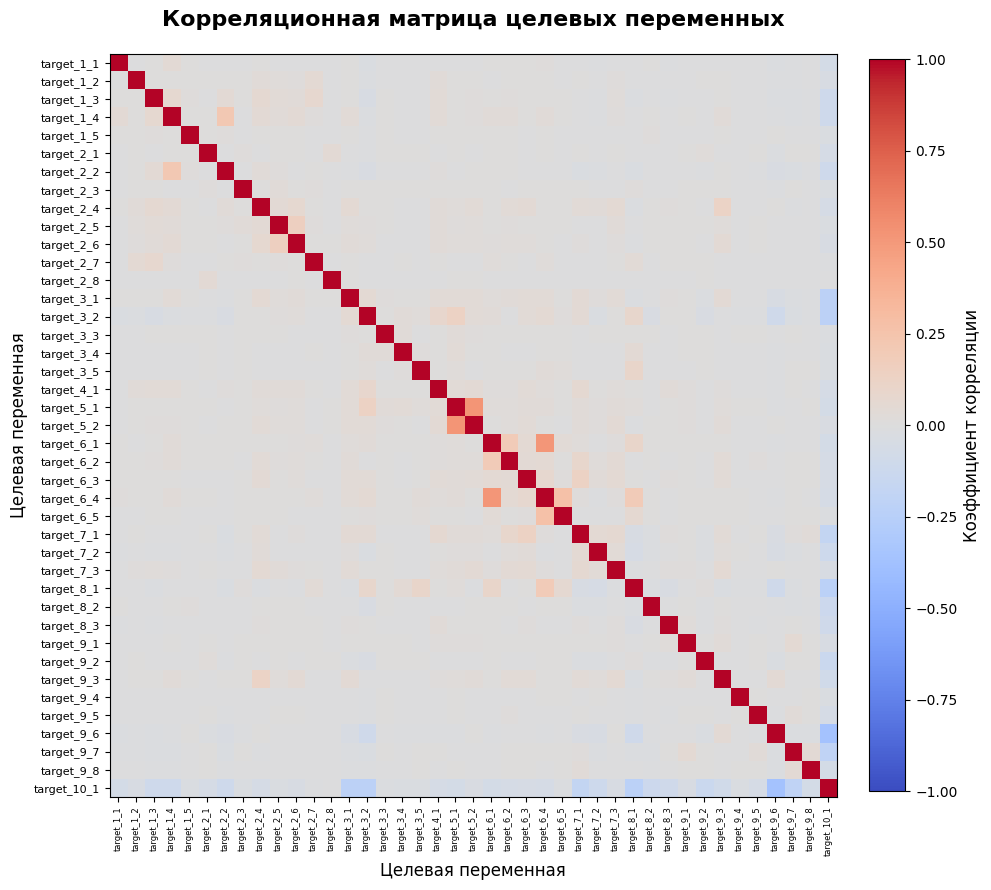

In [12]:
target_corr_matrix = (
    target.select(target_columns)
    .corr()
    .to_numpy()
)
plt.figure(figsize=(10, 9))
im = plt.imshow(target_corr_matrix, cmap = 'coolwarm', vmin = -1, vmax = 1, aspect = 'auto')

cbar = plt.colorbar(im, fraction = 0.046, pad = 0.04)
cbar.set_label('Коэффициент корреляции', fontsize = 12)

plt.title("Корреляционная матрица целевых переменных", fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel("Целевая переменная", fontsize = 12)
plt.ylabel("Целевая переменная", fontsize = 12)

plt.xticks(np.arange(len(target_columns)), target_columns, rotation = 90, fontsize = 6)
plt.yticks(np.arange(len(target_columns)), target_columns, fontsize = 8)

plt.tight_layout()
plt.show()

- На первый взгляд, есть выделяющаяся target_10_1 с отрицательной корреляцией к остальным целевым переменным.
- Внутри целевых переменных с 3 по 7 группу есть заметная внутри-групповая корреляция.
- Небольшая корреляция есть и между целевыми переменными из 1 и 2 групп, в частности между target_1_4 и target_2_2.

In [13]:
target

target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,target_2_6,target_2_7,target_2_8,target_3_1,target_3_2,target_3_3,target_3_4,target_3_5,target_4_1,target_5_1,target_5_2,target_6_1,target_6_2,target_6_3,target_6_4,target_6_5,target_7_1,target_7_2,target_7_3,target_8_1,target_8_2,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
# Top correlated column pairs (unique, sorted by |corr|)
if "target_columns" not in globals():
    target_columns = [c for c in target.columns if c.startswith("target")]

if "target_corr_matrix" not in globals():
    target_corr_matrix = target.select(target_columns).corr().to_numpy()

corr = np.asarray(target_corr_matrix, dtype=float)
cols = list(target_columns)

# upper triangle indices (exclude diagonal)
i, j = np.triu_indices(len(cols), k=1)
vals = corr[i, j]

# drop NaNs
mask = ~np.isnan(vals)
i, j, vals = i[mask], j[mask], vals[mask]

order = np.argsort(np.abs(vals))[::-1]
TOP_N = 30
order = order[:TOP_N]

top_corr = pl.DataFrame({
    "col_1": [cols[a] for a in i[order]],
    "col_2": [cols[b] for b in j[order]],
    "corr": [float(x) for x in vals[order]],
}).with_columns(
    pl.col("corr").abs().alias("abs_corr")
).sort("abs_corr", descending=True)

top_corr

col_1,col_2,corr,abs_corr
str,str,f64,f64
"""target_5_1""","""target_5_2""",0.517938,0.517938
"""target_6_1""","""target_6_4""",0.514028,0.514028
"""target_9_6""","""target_10_1""",-0.363408,0.363408
"""target_6_4""","""target_6_5""",0.265718,0.265718
"""target_8_1""","""target_10_1""",-0.229191,0.229191
…,…,…,…
"""target_8_3""","""target_10_1""",-0.094732,0.094732
"""target_3_2""","""target_9_6""",-0.094685,0.094685
"""target_9_3""","""target_10_1""",-0.093568,0.093568


In [15]:
# Correlation of train_main features with target_10_1 (row-aligned)
import polars.selectors as cs

y_col = "target_10_1"
assert y_col in target.columns, f"Missing column {y_col} in target"
assert train_main.height == target.height, "train_main and target must have same number of rows"

feature_cols = train_main.select(cs.numeric()).columns
feature_cols = [c for c in feature_cols if c != "customer_id"]

corr_row = (
    train_main.select(feature_cols)
    .with_columns(target.get_column(y_col).alias(y_col))
    .select([pl.corr(pl.col(c), pl.col(y_col)).alias(c) for c in feature_cols])
)

corr_table = (
    corr_row
    .transpose(include_header=True, column_names=["corr"])
    .rename({"column": "feature"})
    .with_columns(pl.col("corr").abs().alias("abs_corr"))
    .sort("abs_corr", descending=True)
)

corr_table = corr_table.to_pandas()
corr_table = corr_table.dropna()
corr_table

,feature,corr,abs_corr
5,cat_feature_48,0.195669,0.195669
6,num_feature_36,-0.181155,0.181155
7,cat_feature_52,0.172431,0.172431
8,cat_feature_46,0.169948,0.169948
9,cat_feature_21,0.164459,0.164459
...,...,...,...
160,num_feature_92,0.001222,0.001222
161,cat_feature_34,0.001037,0.001037
162,num_feature_49,-0.000853,0.000853
163,num_feature_79,-0.000732,0.000732


In [16]:
features_to_check = ["cat_feature_48", "num_feature_36", "cat_feature_46", "cat_feature_52", "cat_feature_21"]


,target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,...,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
cat_feature_48,0.025542,0.004247,-0.038907,-0.030294,0.003457,-0.033377,-0.041758,-0.008882,-0.001001,-0.007637,...,0.021602,-0.021912,-0.092057,-0.031058,-0.009713,-0.036899,-0.121063,-0.113515,-0.048408,0.195669
num_feature_36,0.004243,0.002184,0.045269,0.036522,-0.005631,0.053204,0.019461,0.026792,-0.001707,0.014276,...,-0.040901,0.016774,0.147958,0.034197,0.009620,0.058640,-0.022919,0.108127,0.063982,-0.181155
cat_feature_46,0.015034,0.002953,-0.029614,-0.023451,0.000312,-0.023758,-0.038825,-0.006360,0.000849,-0.005543,...,0.008943,-0.016849,-0.066017,-0.017645,-0.009079,-0.024647,-0.107383,-0.082358,-0.034255,0.169948
cat_feature_52,0.022554,0.003936,-0.020238,-0.012739,0.004697,-0.033976,-0.009905,-0.007812,0.001748,-0.006471,...,0.003676,-0.023795,-0.085531,-0.037114,-0.010393,-0.037362,-0.107332,-0.117661,-0.050831,0.172431
cat_feature_21,0.015880,0.003528,-0.027786,-0.023016,0.000345,-0.022418,-0.037867,-0.005613,0.000370,-0.005424,...,0.007586,-0.016784,-0.059393,-0.016858,-0.008055,-0.023763,-0.107442,-0.080950,-0.032777,0.164459


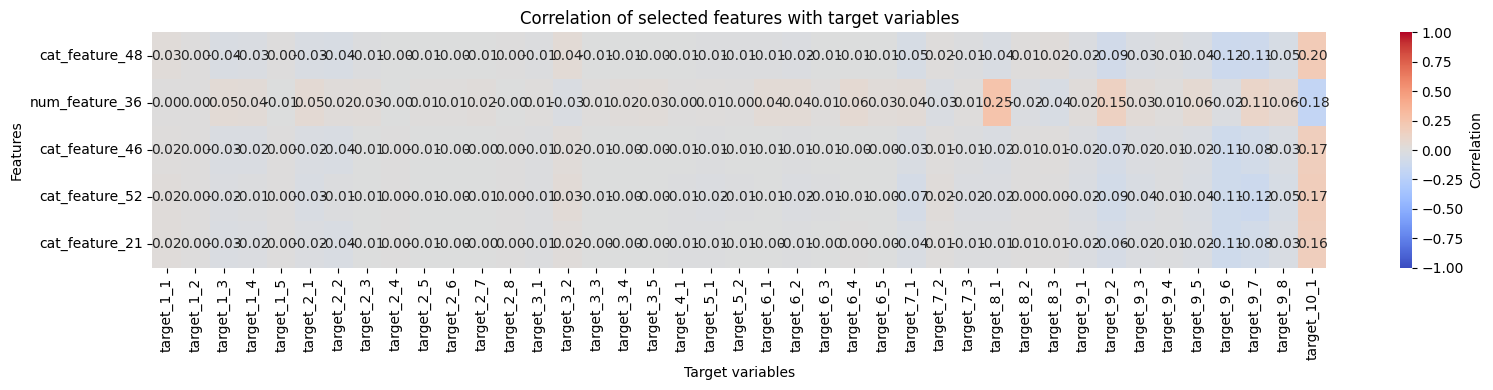

In [17]:
# Correlation map: selected features vs all target variables

# Ensure we have the list of target columns
if "target_columns" not in globals():
    target_columns = [c for c in target.columns if c.startswith("target")]

# Build combined DataFrame with selected features and all targets
combined = pl.concat(
    [
        train_main.select(features_to_check),
        target.select(target_columns),
    ],
    how="horizontal",
)

# Convert to pandas for convenient correlation + heatmap
corr_df = combined.to_pandas()

# Rectangular correlation: rows = features, cols = targets
corr_block = (
    corr_df[features_to_check + target_columns]
    .corr()
    .loc[features_to_check, target_columns]
)

plt.figure(figsize=(max(10, len(target_columns) * 0.4), max(4, len(features_to_check) * 0.6)))
sns.heatmap(
    corr_block,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Correlation"},
)
plt.xlabel("Target variables")
plt.ylabel("Features")
plt.title("Correlation of selected features with target variables")
plt.tight_layout()

corr_block

In [18]:
# Top-100 feature correlations per target (train_main + train_extra)

assert train_main.height == train_extra.height == target.height, "train_main, train_extra and target must have same number of rows"

# Use all feature columns; drop obvious id column from main
main_features = [c for c in train_main.columns if c not in ("customer_id", "customerid", "id")]
extra_features = list(train_extra.columns)

# All target columns
target_cols = [c for c in target.columns if c.startswith("target")]

def _corr_for_side(df_features: pl.DataFrame, feature_cols: list[str], y_series: pl.Series, y_name: str) -> pl.DataFrame:
    """Return long table: feature, corr for one side (main or extra)."""
    corr_row = (
        df_features.select(feature_cols)
        .with_columns(y_series.alias(y_name))
        .select([pl.corr(pl.col(c), pl.col(y_name)).alias(c) for c in feature_cols])
    )
    return (
        corr_row
        .transpose(include_header=True, column_names=["corr"])
        .rename({"column": "feature"})
    )

all_results: list[pl.DataFrame] = []

for y in target_cols:
    y_series = target.get_column(y)

    corr_main = _corr_for_side(train_main, main_features, y_series, y)
    corr_extra = _corr_for_side(train_extra, extra_features, y_series, y)

    corr_all = (
        pl.concat([corr_main, corr_extra])
        .with_columns(pl.col("corr").abs().alias("abs_corr"))
        .drop_nulls("corr")
        .sort("abs_corr", descending=True)
        .head(100)
        .with_columns(pl.lit(y).alias("target"))
        .select("target", "feature", "corr", "abs_corr")
    )

    all_results.append(corr_all)

# Final table: for every target column, its top-100 most correlated features
top100_corrs_by_target = pl.concat(all_results)

# Show a preview
top100_corrs_by_target

target,feature,corr,abs_corr
str,str,f64,f64
"""target_1_1""","""num_feature_9""",NaN,NaN
"""target_1_1""","""num_feature_14""",NaN,NaN
"""target_1_1""","""num_feature_32""",NaN,NaN
"""target_1_1""","""num_feature_80""",NaN,NaN
"""target_1_1""","""num_feature_106""",NaN,NaN
…,…,…,…
"""target_10_1""","""num_feature_1948""",NaN,NaN
"""target_10_1""","""num_feature_1958""",NaN,NaN
"""target_10_1""","""num_feature_1989""",NaN,NaN


In [19]:
# Top-100 feature correlations per target (train_main + train_extra)

assert train_main.height == train_extra.height == target.height, "train_main, train_extra and target must have same number of rows"

# Use all feature columns; drop obvious id column from main
main_features = [c for c in train_main.columns if c not in ("customer_id", "customerid", "id")]
extra_features = list(train_extra.columns)

# All target columns
target_cols = [c for c in target.columns if c.startswith("target")]

def _corr_for_side(df_features: pl.DataFrame, feature_cols: list[str], y_series: pl.Series, y_name: str) -> pl.DataFrame:
    """Return long table: feature, corr for one side (main or extra)."""
    corr_row = (
        df_features.select(feature_cols)
        .with_columns(y_series.alias(y_name))
        .select([pl.corr(pl.col(c), pl.col(y_name)).alias(c) for c in feature_cols])
    )
    return (
        corr_row
        .transpose(include_header=True, column_names=["corr"])
        .rename({"column": "feature"})
    )

all_results: list[pl.DataFrame] = []

for y in target_cols:
    y_series = target.get_column(y)

    corr_main = _corr_for_side(train_main, main_features, y_series, y)
    corr_extra = _corr_for_side(train_extra, extra_features, y_series, y)

    corr_all = (
        pl.concat([corr_main, corr_extra])
        .with_columns(pl.col("corr").abs().alias("abs_corr"))e
        .drop_nulls("corr")
        .sort("abs_corr", descending=True)
        .head(100)
        .with_columns(pl.lit(y).alias("target"))
        .select("target", "feature", "corr", "abs_corr")
    )

    all_results.append(corr_all)

# Final table: for every target column, its top-100 most correlated features
top100_corrs_by_target = pl.concat(all_results)

# Show a preview
top100_corrs_by_target

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1516344032.py, line 34)

In [20]:
import pandas as pd
import numpy as np

train_main = train_main.to_pandas()
train_extra = train_extra.to_pandas()
target = target.to_pandas()


# Combine both feature dataframes column-wise
features = pd.concat([train_main, train_extra], axis=1)

# Result dictionary: target_col_name -> list of top-100 feature names
top_features = {}

for target_col in target.columns:
    # Compute correlation of every feature with this target column
    corr = features.corrwith(target[target_col])     # Series indexed by feature name
    
    # Drop NaN correlations (constant columns, etc.)
    corr = corr.dropna()
    
    # Sort by absolute value descending and take top 100
    top100 = corr.abs().sort_values(ascending=False).head(100).index.tolist()
    
    top_features[target_col] = top100

# Build a tidy dataframe: each column = target name, values = top-100 feature names
top_features_df = pd.DataFrame(top_features)

print(top_features_df)

/Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyboardInterrupt: 

In [ ]:
top_features_df.to_excel('output.xlsx', index=False)

In [22]:
top_features_df = pd.read_excel('top_features.xlsx')

In [ ]:
from collections import defaultdict

# Build sets of top features for each target
feature_sets = {col: set(top_features_df[col]) for col in top_features_df.columns}

# For each target, count how many of its features appear in each OTHER target
overlap_dict = {}

for target_col in feature_sets:
    counter = {}
    for other_col in feature_sets:
        if other_col == target_col:
            continue
        # Count features in common
        counter[other_col] = len(feature_sets[target_col] & feature_sets[other_col])
    overlap_dict[target_col] = counter

# Convert to a DataFrame for a nice view (rows = target, columns = other target)
overlap_df = pd.DataFrame(overlap_dict).fillna(0).astype(int)

print(overlap_df)

             target_1_1  target_1_2  target_1_3  target_1_4  target_1_5  \
target_1_2           57           0          72          67          67   
target_1_3           46          72           0          77          69   
target_1_4           51          67          77           0          71   
target_1_5           58          67          69          71           0   
target_2_1           39          42          44          46          42   
target_2_2           49          63          74          74          68   
target_2_3           38          38          38          41          35   
target_2_4           17          25          31          35          24   
target_2_5           42          48          56          62          52   
target_2_6           15          25          33          37          21   
target_2_7           34          42          42          42          31   
target_2_8           41          47          43          45          41   
target_3_1            8  

In [ ]:
# 1. Count how many times each feature appears globally across the entire dataframe
# stack() flattens the dataframe into one long series of all features
global_counts = top_features_df.stack().value_counts()

# 2. Create a set of features that appear more than once
# If a feature has a count > 1, it means it exists in the current target AND somewhere else
shared_features = set(global_counts[global_counts > 1].index)

repetition_counts = {}

for target_col in top_features_df.columns:
    # Check each feature in the current column
    # .isin(shared_features) returns True if the feature is repeated elsewhere
    # .sum() counts the number of True values
    count = top_features_df[target_col].isin(shared_features).sum()
    
    repetition_counts[target_col] = count

# Result: Dictionary where Key = Target Name, Value = Count of features not unique to this target
print(repetition_counts)

{'target_1_1': np.int64(88), 'target_1_2': np.int64(94), 'target_1_3': np.int64(96), 'target_1_4': np.int64(100), 'target_1_5': np.int64(98), 'target_2_1': np.int64(98), 'target_2_2': np.int64(98), 'target_2_3': np.int64(95), 'target_2_4': np.int64(99), 'target_2_5': np.int64(94), 'target_2_6': np.int64(64), 'target_2_7': np.int64(93), 'target_2_8': np.int64(86), 'target_3_1': np.int64(58), 'target_3_2': np.int64(100), 'target_3_3': np.int64(86), 'target_3_4': np.int64(96), 'target_3_5': np.int64(99), 'target_4_1': np.int64(96), 'target_5_1': np.int64(99), 'target_5_2': np.int64(98), 'target_6_1': np.int64(95), 'target_6_2': np.int64(100), 'target_6_3': np.int64(100), 'target_6_4': np.int64(99), 'target_6_5': np.int64(94), 'target_7_1': np.int64(98), 'target_7_2': np.int64(98), 'target_7_3': np.int64(98), 'target_8_1': np.int64(100), 'target_8_2': np.int64(94), 'target_8_3': np.int64(92), 'target_9_1': np.int64(96), 'target_9_2': np.int64(97), 'target_9_3': np.int64(100), 'target_9_4':

In [27]:
# ============================================================
#  0. IMPORTS & SETTINGS
# ============================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import gc, warnings, time
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ============================================================
#  1. PREPARE DATA
# ============================================================
print("=" * 70)
print("STEP 1 · Merging features & basic prep")
print("=" * 70)

# ---- ids & targets ----
customer_id = train_main.iloc[:, 0].values
target_cols = target.columns[1:].tolist()          # 41 targets

# ---- merge main + extra (drop customer_id in each) ----
X_all = pd.concat(
    [train_main.iloc[:, 1:], train_extra.iloc[:, 1:]],
    axis=1
)
y_all = target[target_cols].copy()

# downcast to save RAM
for c in X_all.columns:
    X_all[c] = pd.to_numeric(X_all[c], downcast="float")

feature_names = X_all.columns.tolist()
print(f"  features : {len(feature_names)}")
print(f"  targets  : {len(target_cols)}")
print(f"  rows     : {len(X_all)}")

# ============================================================
#  2. PER-TARGET FEATURE IMPORTANCE  (LightGBM, sub-sample)
# ============================================================
print("\n" + "=" * 70)
print("STEP 2 · Finding top-K important features per target")
print("=" * 70)

SAMPLE_N  = 120_000          # sub-sample for speed
TOP_K     = 150              # keep top features per target

idx_sample = np.random.choice(len(X_all), size=SAMPLE_N, replace=False)
X_sample   = X_all.iloc[idx_sample].values       # numpy → faster
y_sample   = y_all.iloc[idx_sample]

important_per_target = {}                         # {target: [feat_names]}

t0 = time.time()
for i, col in enumerate(target_cols):
    clf = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.08,
        num_leaves=63,
        subsample=0.7,
        colsample_bytree=0.4,
        min_child_samples=50,
        n_jobs=-1,
        verbose=-1,
        random_state=SEED,
        importance_type="gain",
    )
    clf.fit(X_sample, y_sample[col].values)

    imp = clf.feature_importances_
    top_idx = np.argsort(imp)[::-1][:TOP_K]
    top_feats = [feature_names[j] for j in top_idx if imp[j] > 0]
    important_per_target[col] = top_feats

    print(f"  [{i+1:>2}/{len(target_cols)}]  {col:<30s}  "
          f"top feats kept: {len(top_feats)}")

del X_sample, y_sample; gc.collect()
print(f"  elapsed: {time.time()-t0:.0f}s")

# ============================================================
#  3. FILTER UBIQUITOUS (NOISY) FEATURES
# ============================================================
print("\n" + "=" * 70)
print("STEP 3 · Removing features that appear in > 30/41 targets")
print("=" * 70)

feat_counter = Counter()
for feats in important_per_target.values():
    feat_counter.update(feats)

THRESHOLD = 30
ubiquitous  = {f for f, c in feat_counter.items() if c > THRESHOLD}
print(f"  ubiquitous features (removed) : {len(ubiquitous)}")

# per-target cleaned lists
clean_per_target = {}
for col, feats in important_per_target.items():
    clean_per_target[col] = [f for f in feats if f not in ubiquitous]

# global union of remaining features
selected_union = sorted(
    {f for feats in clean_per_target.values() for f in feats}
)
print(f"  discriminative features kept  : {len(selected_union)}")

# ============================================================
#  4. BUILD FILTERED DATAFRAME
# ============================================================
print("\n" + "=" * 70)
print("STEP 4 · Creating filtered X matrix")
print("=" * 70)

X_filtered = X_all[selected_union].copy()
print(f"  shape: {X_filtered.shape}")
del X_all, train_main, train_extra; gc.collect()

# ============================================================
#  5. TRAIN / VALIDATION SPLIT
# ============================================================
print("\n" + "=" * 70)
print("STEP 5 · Train / validation split (85-15)")
print("=" * 70)

idx_tr, idx_val = train_test_split(
    np.arange(len(X_filtered)), test_size=0.15, random_state=SEED
)
print(f"  train : {len(idx_tr)}   val : {len(idx_val)}")

# ============================================================
#  6. H2O AutoML  – one model per target
# ============================================================
print("\n" + "=" * 70)
print("STEP 6 · H2O AutoML training (per target)")
print("=" * 70)

import h2o
from h2o.automl import H2OAutoML

h2o.init(
    max_mem_size="48G",        # adjust to your machine
    nthreads=-1,
)

# ---- upload ONCE (features + all targets) ----
full_df = pd.concat([X_filtered, y_all], axis=1)
train_h2o_pd = full_df.iloc[idx_tr]
val_h2o_pd   = full_df.iloc[idx_val]

h_train = h2o.H2OFrame(train_h2o_pd)
h_val   = h2o.H2OFrame(val_h2o_pd)

for col in target_cols:
    h_train[col] = h_train[col].asfactor()
    h_val[col]   = h_val[col].asfactor()

del full_df, train_h2o_pd, val_h2o_pd; gc.collect()

# ---- train 41 AutoML models ----
best_models   = {}
val_pred_dict = {}
auc_dict      = {}

MAX_RUNTIME   = 420       # seconds per target  (7 min)
MAX_MODELS    = 25

for i, col in enumerate(target_cols):
    print(f"\n>>> Target {i+1}/{len(target_cols)}: {col}")

    # prefer per-target features; fall back to full union if too few
    predictors = clean_per_target[col] if len(clean_per_target[col]) >= 15 \
                 else selected_union

    aml = H2OAutoML(
        max_runtime_secs=MAX_RUNTIME,
        max_models=MAX_MODELS,
        seed=SEED,
        sort_metric="AUC",
        balance_classes=True,
        exclude_algos=["DeepLearning"],
        verbosity="warn",
        project_name=f"aml_{col}",
    )

    aml.train(
        x=predictors,
        y=col,
        training_frame=h_train,
        leaderboard_frame=h_val,
    )

    leader = aml.leader
    best_models[col] = leader

    # validation probabilities
    preds   = leader.predict(h_val)
    p1      = preds["p1"].as_data_frame(use_pandas=True).values.ravel()
    val_pred_dict[col] = p1

    auc = roc_auc_score(y_all[col].values[idx_val], p1)
    auc_dict[col] = auc
    print(f"    leader : {leader.model_id}")
    print(f"    AUC    : {auc:.5f}")

# ============================================================
#  7. OVERALL MACRO ROC-AUC
# ============================================================
print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

y_true_val = y_all.iloc[idx_val][target_cols].values
y_pred_val = np.column_stack([val_pred_dict[c] for c in target_cols])

macro_auc = roc_auc_score(y_true_val, y_pred_val, average="macro")

print(f"\n{'MACRO ROC-AUC':>25s} : {macro_auc:.5f}\n")
print(f"{'Target':<35s} {'AUC':>8s}")
print("-" * 45)
for col in target_cols:
    print(f"  {col:<33s} {auc_dict[col]:.5f}")

# ============================================================
#  8. SAVE MODELS & PREDICTIONS
# ============================================================
print("\n" + "=" * 70)
print("STEP 8 · Saving artefacts")
print("=" * 70)

import os, pickle

os.makedirs("artefacts", exist_ok=True)

# save H2O models
for col, mdl in best_models.items():
    path = h2o.save_model(model=mdl, path="artefacts", force=True)
    print(f"  saved {col} → {path}")

# save selected features
with open("artefacts/selected_features.pkl", "wb") as f:
    pickle.dump({
        "selected_union": selected_union,
        "clean_per_target": clean_per_target,
        "ubiquitous": ubiquitous,
    }, f)

# save val predictions for analysis
np.save("artefacts/val_pred.npy", y_pred_val)
np.save("artefacts/val_true.npy", y_true_val)

print("\nDone ✓")
h2o.cluster().shutdown(prompt=False)

STEP 1 · Merging features & basic prep
  features : 1495
  targets  : 40
  rows     : 750000

STEP 2 · Finding top-K important features per target
  [ 1/40]  target_1_2                      top feats kept: 150
  [ 2/40]  target_1_3                      top feats kept: 150
  [ 3/40]  target_1_4                      top feats kept: 150
  [ 4/40]  target_1_5                      top feats kept: 150
  [ 5/40]  target_2_1                      top feats kept: 150
  [ 6/40]  target_2_2                      top feats kept: 150
  [ 7/40]  target_2_3                      top feats kept: 150
  [ 8/40]  target_2_4                      top feats kept: 150
  [ 9/40]  target_2_5                      top feats kept: 150
  [10/40]  target_2_6                      top feats kept: 150
  [11/40]  target_2_7                      top feats kept: 150
  [12/40]  target_2_8                      top feats kept: 150
  [13/40]  target_3_1                      top feats kept: 150
  [14/40]  target_3_2             

H2OStartupError: Cannot start local server: h2o.jar not found. Paths searched:
    /Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
    /Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/h2o_jar/h2o.jar
    /usr/local/h2o_jar/h2o.jar
    /Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/local/h2o_jar/h2o.jar
    /Users/aleksandrcuvpilo/Library/Python/3.12/h2o_jar/h2o.jar
    /Users/aleksandrcuvpilo/Desktop/Programming/vscode/parser/h2o_jar/h2o.jar


In [ ]:
# ============================================================
#  6-ALT. LightGBM + Optuna  (drop-in replacement for Step 6)
# ============================================================
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

best_models   = {}
val_pred_dict = {}
auc_dict      = {}

X_tr = X_filtered.iloc[idx_tr]
X_va = X_filtered.iloc[idx_val]

for i, col in enumerate(target_cols):
    print(f"\n>>> Target {i+1}/{len(target_cols)}: {col}")

    predictors = clean_per_target[col] if len(clean_per_target[col]) >= 15 \
                 else selected_union

    y_tr = y_all[col].values[idx_tr]
    y_va = y_all[col].values[idx_val]

    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 300, 2000),
            "max_depth":         trial.suggest_int("max_depth", 4, 10),
            "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
            "learning_rate":     trial.suggest_float("lr", 0.01, 0.15, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample", 0.3, 1.0),
            "min_child_samples": trial.suggest_int("min_child", 10, 200),
            "reg_alpha":         trial.suggest_float("alpha", 1e-8, 10, log=True),
            "reg_lambda":        trial.suggest_float("lam", 1e-8, 10, log=True),
            "random_state":      SEED,
            "n_jobs":            -1,
            "verbose":           -1,
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        aucs = []
        for tr_i, va_i in skf.split(X_tr[predictors], y_tr):
            clf = lgb.LGBMClassifier(**params)
            clf.fit(
                X_tr[predictors].iloc[tr_i], y_tr[tr_i],
                eval_set=[(X_tr[predictors].iloc[va_i], y_tr[va_i])],
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            aucs.append(roc_auc_score(
                y_tr[va_i],
                clf.predict_proba(X_tr[predictors].iloc[va_i])[:, 1],
            ))
        return np.mean(aucs)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=40, timeout=300)

    best_p = study.best_params
    best_p.update({"random_state": SEED, "n_jobs": -1, "verbose": -1})
    clf = lgb.LGBMClassifier(**best_p)
    clf.fit(
        X_tr[predictors], y_tr,
        eval_set=[(X_va[predictors], y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    p1 = clf.predict_proba(X_va[predictors])[:, 1]
    auc = roc_auc_score(y_va, p1)
    print(f"    best AUC: {auc:.5f}  params: {study.best_params}")

    best_models[col]   = clf
    val_pred_dict[col] = p1
    auc_dict[col]      = auc


>>> Target 1/40: target_1_2
    best AUC: 0.79824  params: {'n_estimators': 491, 'max_depth': 6, 'num_leaves': 78, 'lr': 0.03635049912903237, 'subsample': 0.8069697471926744, 'colsample': 0.44250892756048565, 'min_child': 85, 'alpha': 4.957448743006599e-06, 'lam': 1.1447043610869456}

>>> Target 2/40: target_1_3
    best AUC: 0.87352  params: {'n_estimators': 1925, 'max_depth': 5, 'num_leaves': 214, 'lr': 0.019173913293734024, 'subsample': 0.6601807356856888, 'colsample': 0.3068723704708487, 'min_child': 176, 'alpha': 7.065244871284124e-06, 'lam': 3.038632130529888e-05}

>>> Target 3/40: target_1_4
    best AUC: 0.82305  params: {'n_estimators': 1139, 'max_depth': 6, 'num_leaves': 240, 'lr': 0.04536519976050093, 'subsample': 0.8874849985054136, 'colsample': 0.5676897049845349, 'min_child': 168, 'alpha': 0.0003744032489032461, 'lam': 0.9319931943127371}

>>> Target 4/40: target_1_5
    best AUC: 0.88463  params: {'n_estimators': 964, 'max_depth': 5, 'num_leaves': 90, 'lr': 0.0286612509